<a href="https://colab.research.google.com/github/ajrotech/NCAI_Internship-/blob/main/Task_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Handwritten Digit Recognition**


There is dataset 70000 images of handwritten numbers from 0 to 9, in which 60000 are training set and 10000 are testing set. Each image is 28*28 pixel.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [ ]:
print(X_train.shape)

(60000, 28, 28, 1)


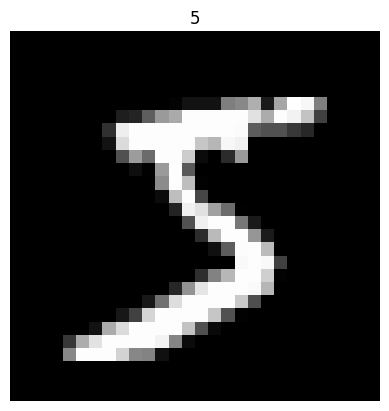

In [42]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [ ]:
print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 60000
Testing: 10000


In [ ]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [ ]:
for digit in range(10):
    print(digit, np.sum(y_train == digit))

0 5923
1 6742
2 5958
3 6131
4 5842
5 5421
6 5918
7 6265
8 5851
9 5949


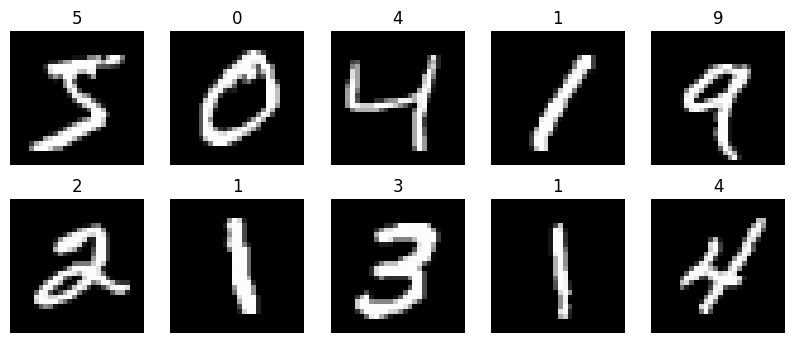

In [ ]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

**Data Processing**

Check Pixel Values

In [ ]:
print(X_train[0].min())
print(X_train[0].max())

0
255


Normalize

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

**Build CNN**

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')

])

In [ ]:
Conv2D(32,(3,3))

<Conv2D name=conv2d_5, built=False>

## **Compile**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### **Train**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9566 - loss: 0.1441 - val_accuracy: 0.9789 - val_loss: 0.0703
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9860 - loss: 0.0448 - val_accuracy: 0.9865 - val_loss: 0.0446
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9911 - loss: 0.0294 - val_accuracy: 0.9902 - val_loss: 0.0356
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9896 - val_loss: 0.0364
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9945 - loss: 0.0166 - val_accuracy: 0.9884 - val_loss: 0.0417


In [43]:
model.save("mnist_cnn_model.keras")

## **Evaluate**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9883 - loss: 0.0380
Accuracy: 0.9883000254631042


## **Predict**

In [ ]:
prediction = model.predict(X_test[:1])

print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
7


In [ ]:
print(y_test[0])

7


# **Show Prediction**

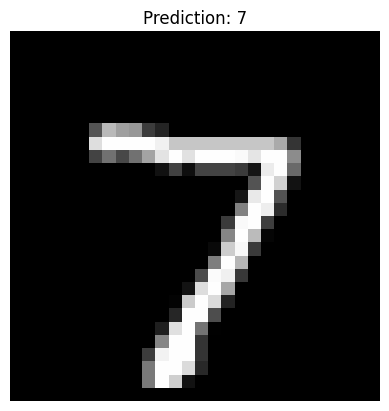

In [ ]:
plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.title(f"Prediction: {np.argmax(prediction)}")
plt.axis("off")
plt.show()